In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
np.random.seed(42)

### Why Neural Networks?

Linear regression assumes a simple linear relationship:
- Every extra unit of a feature changes the output by a constant amount.
- No interaction, no nonlinearity.

But real-world problems:
- Nonlinear effects
- Interaction between variables
- Thresholds and plateaus

Neural Networks can learn these patterns automatically.
Below is a toy house price example.

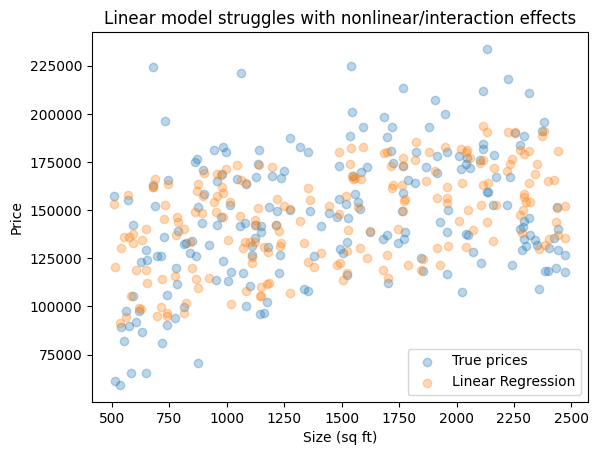

In [ ]:
# Toy data: house price depends nonlinearly on size and location_score
n = 200
size = np.random.uniform(500, 2500, n)  # living area
loc = np.random.uniform(0, 1, n)        # location score

# True nonlinear relationship
price = 50_000 + 80 * size + 40_000 * loc + 30_000 * (loc > 0.7) - 0.02 * (size**2)
price = price + np.random.normal(0, 20_000, n)

X = np.column_stack([size, loc])

linreg = LinearRegression().fit(X, price)
pred_lin = linreg.predict(X)

plt.scatter(size, price, alpha=0.3, label="True prices")
plt.scatter(size, pred_lin, alpha=0.3, label="Linear Regression")
plt.xlabel("Size (sq ft)")
plt.ylabel("Price")
plt.legend()
plt.title("Linear model struggles with nonlinear/interaction effects")
plt.show()

### Structure of a Simple Neural Network

We focus on a 1-hidden-layer network:

Input layer (features X)
→ Hidden layer (neurons with activation function)
→ Output layer (prediction)

Example with 2 inputs, 2 hidden neurons, 1 output:

Hidden:

- h1 = f(w11 * x1 + w12 * x2 + b1)
- h2 = f(w21 * x1 + w22 * x2 + b2)

Output:
y_hat = w31 * h1 + w32 * h2 + b3  (for regression)

This shows:
- Parameters = weights + biases
- Activation function f introduces nonlinearity

In [ ]:
def relu(z):
    return np.maximum(0, z)

def simple_network(x1, x2,
                   w11=1.0, w12=-1.0, b1=0.0,
                   w21=-0.5, w22=1.0, b2=0.5,
                   w31=1.0, w32=1.0, b3=0.0):
    # Hidden layer
    h1 = relu(w11*x1 + w12*x2 + b1)
    h2 = relu(w21*x1 + w22*x2 + b2)
    # Output layer (linear)
    y_hat = w31*h1 + w32*h2 + b3
    return y_hat

# Example
print(simple_network(1.0, 2.0))

2.0


### Activation Functions

Activation functions introduce nonlinearity.

Common choices:
- Sigmoid: smooth, used for probabilities
- Tanh: similar but centered at 0
- ReLU: simple and works well in practice

Without activation functions, stacked layers collapse to one linear model.

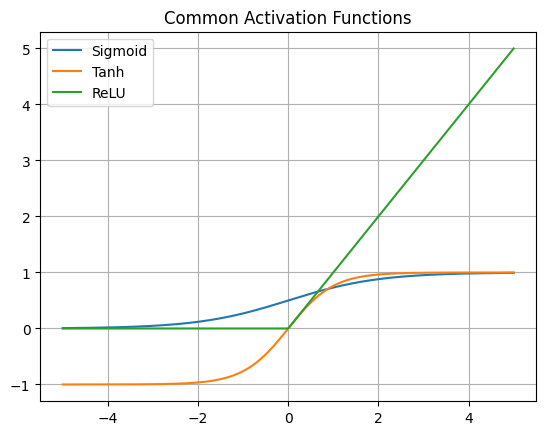

In [ ]:
x = np.linspace(-5, 5, 400)
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)
relu_vals = np.maximum(0, x)

plt.plot(x, sigmoid, label="Sigmoid")
plt.plot(x, tanh, label="Tanh")
plt.plot(x, relu_vals, label="ReLU")
plt.title("Common Activation Functions")
plt.legend()
plt.grid(True)
plt.show()

**Universal Approximation (intuition)**:
With enough hidden neurons and a non-linear activation, a 1-hidden-layer NN can approximate any continuous function.
In practice we use multiple layers for efficiency.

### How Many Parameters?

For:
- F input features
- H hidden layers
- M neurons each hidden layer
- T outputs

Parameters grow quickly → risk of overfitting, need enough data + regularization.

In [ ]:
def count_params(F, H, M, T):
    # (F+1)*M for first hidden layer (incl. bias)
    # (M+1)*M for each additional hidden layer
    # (M+1)*T for output layer
    if H == 0:
        return (F + 1) * T
    params = (F + 1) * M
    if H > 1:
        params += (H - 1) * (M + 1) * M
    params += (M + 1) * T
    return params

print("Example: F=4, H=3, M=30, T=1 =>", count_params(4,3,30,1), "parameters")

Example: F=4, H=3, M=30, T=1 => 2041 parameters


### Gradient Descent (1D Example)

Goal: minimize
y(x) = x^2 - 8x + 20

Gradient:
dy/dx = 2x - 8

Update rule:
x_new = x_old - learning_rate * (2x_old - 8)

In [ ]:
def gradient(x):
    return 2*x - 8

def run_gd(x0, lr, steps=15):
    xs = [x0]
    for _ in range(steps):
        x0 = x0 - lr * gradient(x0)
        xs.append(x0)
    return xs

x0 = 1.0
lrs = [0.02, 0.2, 1.2]
titles = ["Learning rate = 0.02 (too small)",
          "Learning rate = 0.2 (good)",
          "Learning rate = 1.2 (too large)"]
true_min = 4.0

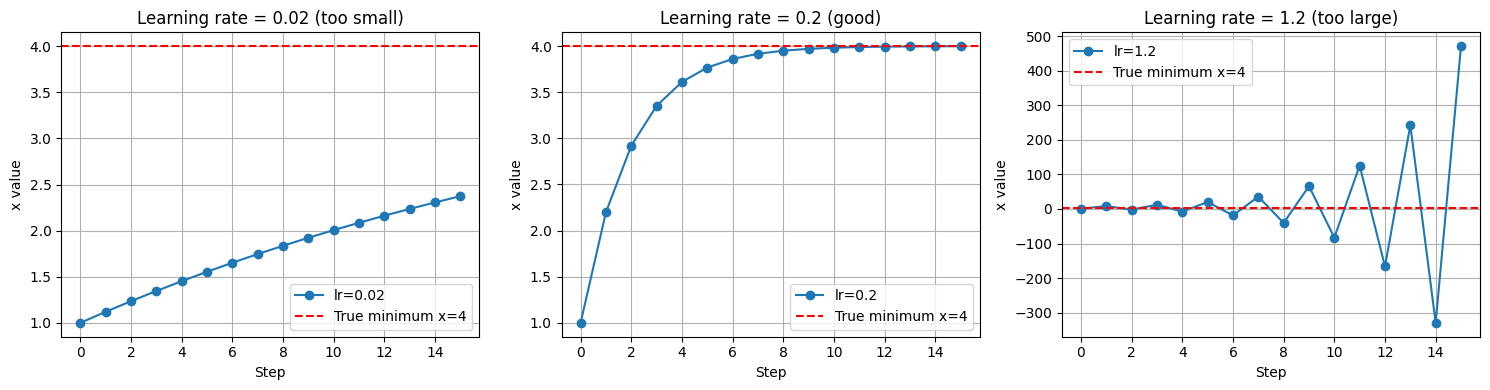

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, lr, title in zip(axes, lrs, titles):
    xs = run_gd(x0, lr)
    ax.plot(xs, marker="o", label=f"lr={lr}")
    ax.axhline(true_min, linestyle="--", color="red", label="True minimum x=4")
    ax.set_xlabel("Step")
    ax.set_ylabel("x value")
    ax.set_title(title)
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

### Early Stopping: Preventing Overfitting

Training a neural network for too many epochs can lead to **overfitting** — the model keeps improving on the training data but starts performing worse on new data.  
The **EarlyStopping** callback monitors validation loss and stops training automatically once the model stops improving.

In [ ]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

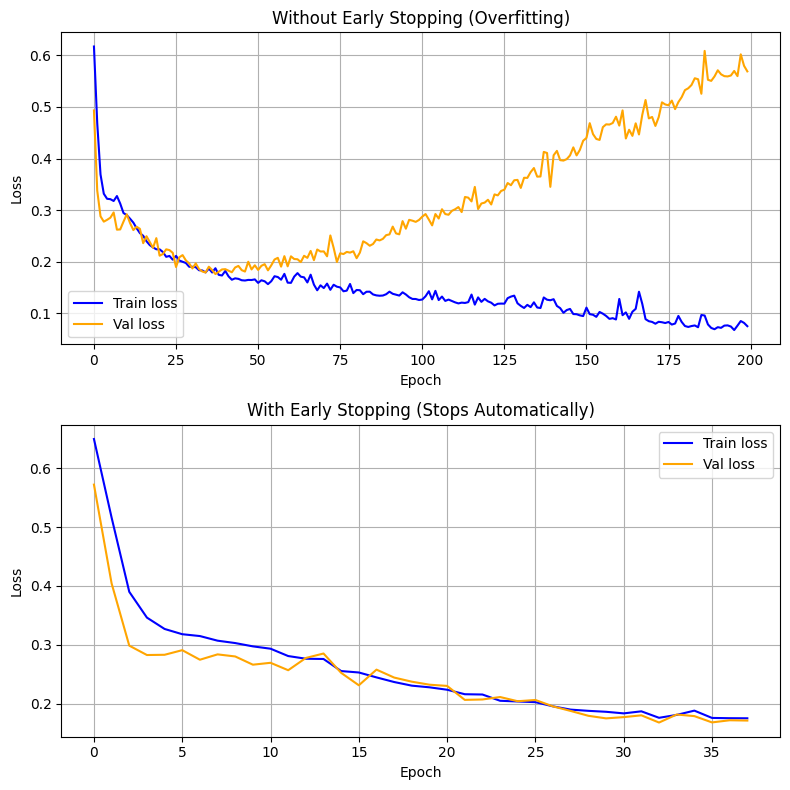

In [ ]:
# 1) Generate toy data
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.4, random_state=42)

# 2) Define a neural network model
def build_model():
    model = Sequential([
        Dense(128, input_dim=2, activation='relu'),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# 3) Train model without EarlyStopping
model_no_stop = build_model()
history_no_stop = model_no_stop.fit(
    X_train, y_train,
    epochs=200,
    batch_size=16,
    validation_data=(X_val, y_val),
    verbose=0
)

# 4) Train model with EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_stop = build_model()
history_stop = model_stop.fit(
    X_train, y_train,
    epochs=200,
    batch_size=16,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=0
)

# 5) Display two plots
fig, axes = plt.subplots(2, 1, figsize=(8, 8))

axes[0].plot(history_no_stop.history['loss'], label='Train loss', color='blue')
axes[0].plot(history_no_stop.history['val_loss'], label='Val loss', color='orange')
axes[0].set_title("Without Early Stopping (Overfitting)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_stop.history['loss'], label='Train loss', color='blue')
axes[1].plot(history_stop.history['val_loss'], label='Val loss', color='orange')
axes[1].set_title("With Early Stopping (Stops Automatically)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

**Interpretation of the Two Plots**

**Top plot – Without Early Stopping:**
- The **blue line** (training loss) keeps decreasing steadily.
- The **orange line** (validation loss) first decreases, then starts rising again.
- This shows **overfitting**: the model keeps improving on the training data but performs worse on unseen data.

**Bottom plot – With Early Stopping:**
- The model monitors validation loss during training.
- Once validation loss stops improving for 5 consecutive epochs (`patience=5`), training stops automatically.
- The model parameters are restored to the epoch where validation loss was at its lowest.
- This prevents overfitting and achieves better generalization.

**In summary:**
Early stopping is a practical way to avoid overfitting by monitoring validation performance and halting training at the optimal point.

### Adaptive vs Fixed Learning Rate

Traditional gradient descent uses a *fixed* learning rate.  
Adaptive methods (like **Adam**, **AdaGrad**, **RMSProp**) automatically adjust the step size for each parameter.

This helps the algorithm:
- Take smaller steps in steep directions.
- Take larger steps in flat directions.
- Converge faster and more stably.

In [ ]:
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

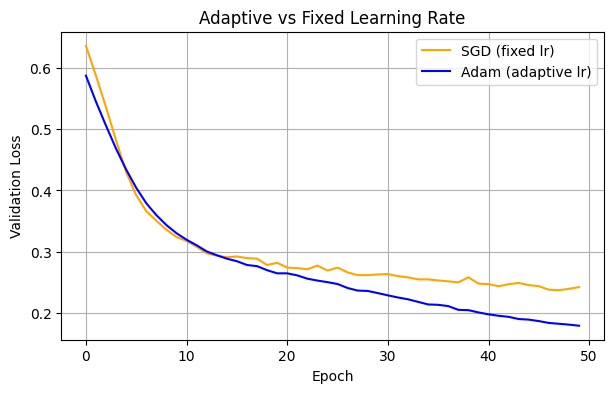

In [ ]:
# Generate toy data
X, y = make_moons(n_samples=800, noise=0.25, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

# Define two identical models with different optimizers
def build_model(optimizer):
    model = Sequential([
        Dense(16, input_dim=2, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# SGD model
model_sgd = build_model(SGD(learning_rate=0.05))
history_sgd = model_sgd.fit(X_train, y_train, epochs=50, batch_size=32,
                            validation_data=(X_val, y_val), verbose=0)

# Adam model
model_adam = build_model(Adam())
history_adam = model_adam.fit(X_train, y_train, epochs=50, batch_size=32,
                              validation_data=(X_val, y_val), verbose=0)

# Compare losses
plt.figure(figsize=(7,4))
plt.plot(history_sgd.history['val_loss'], label='SGD (fixed lr)', color='orange')
plt.plot(history_adam.history['val_loss'], label='Adam (adaptive lr)', color='blue')
plt.title("Adaptive vs Fixed Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

### Interpretation
- **SGD (orange):** The loss decreases slowly and may fluctuate.
- **Adam (blue):** Converges faster and more smoothly.
- Adaptive optimizers automatically tune learning rates based on past gradients.

### Which Optimizer Was Used in the Stopping Rule Example?

We didn’t specify any optimizer in `model.compile()`, so Keras automatically used **RMSProp** by default.

**RMSProp** is an *adaptive learning rate optimizer* that adjusts the step size for each parameter based on recent gradient values. It helps training converge faster and more smoothly than plain **SGD**. **Adam** actually builds on RMSProp — it combines RMSProp’s adaptive learning rate with **momentum**, making it even more stable and widely used in practice.

### Putting It All Together: Building a Neural Network in Python

Now that we understand how a neural network learns (activation functions, gradient descent, and optimization), so we combine the key ideas:

- Input features => hidden layers => output layer
- ReLU in hidden layers for nonlinearity
- Sigmoid in the output layer for binary classification
- Adam optimizer for efficient training with adaptive learning rates

Below is a minimal working example with:
- 10 input features
- Two hidden layers with 32 neurons each
- One output neuron predicting a probability (0–1)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split

In [ ]:
# 1) Create a toy dataset with 10 features
np.random.seed(42)
X = np.random.rand(1000, 10)                 # 1000 samples, 10 features
y = (np.sum(X, axis=1) > 5).astype(int)      # simple nonlinear rule: sum > 5 => class 1

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

# 2) Define the neural network
model = Sequential()
model.add(Dense(32, input_dim=10, activation='relu'))   # Hidden layer 1
model.add(Dense(32, activation='relu'))                 # Hidden layer 2
model.add(Dense(1, activation='sigmoid'))               # Output layer

# 3) Compile the model
model.compile(
    loss='binary_crossentropy',     # binary classification loss
    optimizer=Adam(),               # adaptive learning rate optimizer
    metrics=['accuracy']
)

# 4) Train the model
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

# 5) Evaluate on validation set
loss, acc = model.evaluate(X_val, y_val, verbose=0)
print(f"Validation Accuracy: {acc:.3f}")

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4783 - loss: 0.6921 - val_accuracy: 0.5000 - val_loss: 0.6866
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5475 - loss: 0.6788 - val_accuracy: 0.5767 - val_loss: 0.6774
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6392 - loss: 0.6673 - val_accuracy: 0.6300 - val_loss: 0.6658
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6223 - loss: 0.6566 - val_accuracy: 0.6867 - val_loss: 0.6503
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6858 - loss: 0.6406 - val_accuracy: 0.7133 - val_loss: 0.6330
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6977 - loss: 0.6219 - val_accuracy: 0.7633 - val_loss: 0.6146
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7521 - loss: 0.6033 - val_accuracy: 0.6900 - val_loss: 0.5994
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7300 - loss: 0.5766 - val_accuracy: 0.7867 - val_loss:

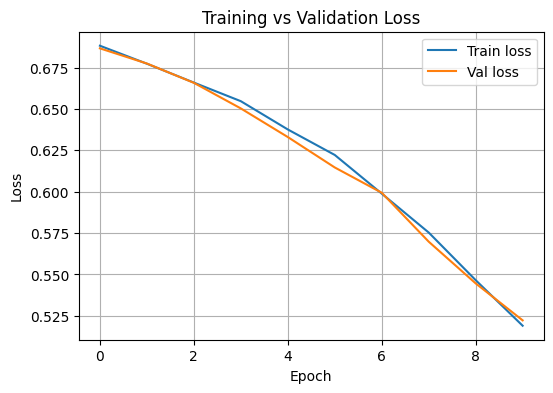

In [ ]:
# Plot training vs validation loss
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()